# 04 — Fine-tuning DistilBERT per Sentiment Analysis

Questo notebook implementa il fine-tuning di **DistilBERT** (`distilbert-base-uncased`) 
per la classificazione del sentiment a 3 classi sulle recensioni Amazon Beauty.

**Perché DistilBERT?**
- È una versione distillata di BERT: 40% più piccolo, 60% più veloce, preserva il 97% delle performance.
- Ideale per fine-tuning su hardware limitato (Google Colab, laptop).
- Pre-trained su una grande quantità di testo inglese, cattura il contesto semantico che TF-IDF non riesce a modellare.

**Differenza chiave rispetto alle baseline:**
- Le baseline (TF-IDF + SVM/XGBoost) trattano il testo come bag-of-words, perdendo il contesto.
- DistilBERT utilizza self-attention per catturare dipendenze a lungo raggio e sfumature semantiche.
- Questo è particolarmente utile per il sentiment, dove negazioni, ironia e sfumature sono cruciali.

**Nota:** Per eseguire questo notebook con tempi ragionevoli, è consigliato l'uso di una GPU (es. Google Colab con GPU T4).

In [1]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset

from src.evaluation import (
    print_classification_metrics, 
    plot_confusion_matrix,
    get_metrics_dict
)

# Verifica GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


## 1. Caricamento dataset preprocessato

In [2]:
# Carica il dataset preprocessato dal notebook 02
df = pd.read_csv('../data/amazon_beauty_clean.csv')

print(f"Dataset: {df.shape[0]} righe")
print(f"\nDistribuzione classi:")
print(df['sentiment_class'].value_counts().sort_index())

# Per il transformer usiamo il testo ORIGINALE (non preprocessato per TF-IDF)
# perché DistilBERT ha il proprio tokenizer e beneficia del testo naturale
# Se 'text' non è disponibile, usiamo 'text_final'
text_col = 'text' if 'text' in df.columns else 'text_final'
print(f"\nColonna testo utilizzata: {text_col}")

Dataset: 14670 righe

Distribuzione classi:
sentiment_class
0    4890
1    4890
2    4890
Name: count, dtype: int64

Colonna testo utilizzata: text


## 2. Preparazione dati

In [3]:
# Rimuovi eventuali NaN
df = df.dropna(subset=[text_col, 'sentiment_class']).reset_index(drop=True)

# Split stratificato: 80% train, 10% validation, 10% test
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['sentiment_class']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['sentiment_class']
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nTrain distribution:\n{train_df['sentiment_class'].value_counts().sort_index()}")

Train: 11736 | Val: 1467 | Test: 1467

Train distribution:
sentiment_class
0    3912
1    3912
2    3912
Name: count, dtype: int64


## 3. Tokenizzazione con DistilBERT

In [4]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128  # Lunghezza massima dei token (le recensioni beauty sono generalmente corte)

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_data(df, text_col, tokenizer, max_length=MAX_LENGTH):
    """
    Tokenizza un DataFrame e lo converte in un HuggingFace Dataset.
    """
    texts = df[text_col].tolist()
    labels = df['sentiment_class'].tolist()
    
    encodings = tokenizer(
        texts,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors=None  # restituisce liste, non tensori
    )
    
    dataset = Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': labels
    })
    
    dataset.set_format('torch')
    return dataset

print("Tokenizzazione in corso...")
train_dataset = tokenize_data(train_df, text_col, tokenizer)
val_dataset = tokenize_data(val_df, text_col, tokenizer)
test_dataset = tokenize_data(test_df, text_col, tokenizer)

print(f"✅ Tokenizzazione completata")
print(f"   Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\rossa\uniProj\REACT\venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rossa\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizzazione in corso...
✅ Tokenizzazione completata
   Train: 11736 | Val: 1467 | Test: 1467


## 4. Configurazione del modello

In [5]:
NUM_LABELS = 3  # Negativo, Neutro, Positivo

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

# Conta parametri
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametri totali: {total_params:,}")
print(f"Parametri trainabili: {trainable_params:,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parametri totali: 66,955,779
Parametri trainabili: 66,955,779


## 5. Training

In [6]:
def compute_metrics(eval_pred):
    """
    Funzione di callback per calcolare le metriche durante il training.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'f1_weighted': f1_score(labels, predictions, average='weighted'),
    }


# Configurazione training
training_args = TrainingArguments(
    output_dir='../models/distilbert-sentiment',
    
    # Iperparametri
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=500,
    
    # Evaluation
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    
    # Logging
    logging_dir='../models/distilbert-sentiment/logs',
    logging_steps=100,
    report_to='none',  # No MLflow/W&B
    
    # Seed
    seed=42,
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("🚀 Inizio training...")
print(f"   Epoche: {training_args.num_train_epochs}")
print(f"   Batch size: {training_args.per_device_train_batch_size}")
print(f"   Learning rate: {training_args.learning_rate}")
print(f"   Device: {training_args.device}")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


🚀 Inizio training...
   Epoche: 3
   Batch size: 16
   Learning rate: 2e-05
   Device: cuda:0


In [7]:
# Esegui il training
train_result = trainer.train()

print(f"\n✅ Training completato!")
print(f"   Training loss: {train_result.training_loss:.4f}")
print(f"   Training time: {train_result.metrics['train_runtime']:.1f}s")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.456495,0.462150,0.812543,0.807685,0.807685
2,0.342173,0.428553,0.837082,0.838206,0.838206
3,0.244245,0.469439,0.841854,0.841767,0.841767


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Training completato!
   Training loss: 0.4204
   Training time: 213.7s


## 6. Valutazione sul test set


📊 Risultati: DistilBERT fine-tuned

Accuracy:  0.8173
F1 Macro:  0.8173
F1 Weight: 0.8173

              precision    recall  f1-score   support

    Negativo       0.86      0.87      0.86       489
      Neutro       0.73      0.73      0.73       489
    Positivo       0.87      0.85      0.86       489

    accuracy                           0.82      1467
   macro avg       0.82      0.82      0.82      1467
weighted avg       0.82      0.82      0.82      1467

💾 Confusion matrix salvata in: ../results/figures/cm_distilbert.png


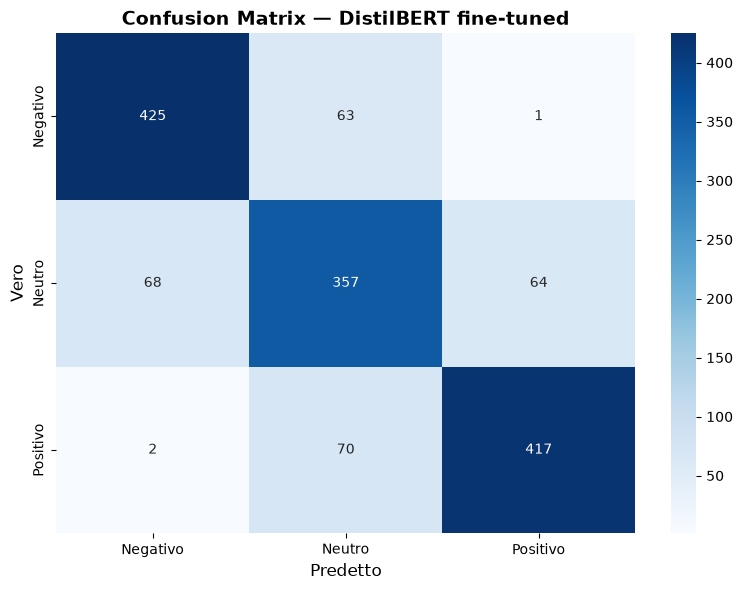

In [8]:
# Predizioni sul test set
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = test_df['sentiment_class'].values

# Metriche
print_classification_metrics(y_true, y_pred, model_name="DistilBERT fine-tuned")

# Confusion Matrix
plot_confusion_matrix(
    y_true, y_pred, 
    model_name="DistilBERT fine-tuned",
    save_path='../results/figures/cm_distilbert.png'
)

💾 Confusion matrix salvata in: ../results/figures/cm_distilbert_normalized.png


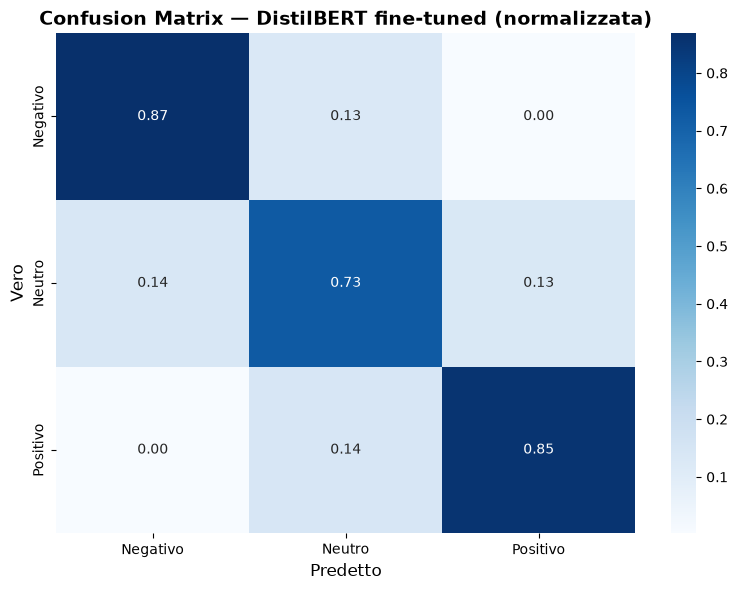

In [9]:
# Confusion matrix normalizzata
plot_confusion_matrix(
    y_true, y_pred, 
    model_name="DistilBERT fine-tuned (normalizzata)",
    normalize='true',
    save_path='../results/figures/cm_distilbert_normalized.png'
)

## 7. Salvataggio metriche per il confronto

In [10]:
import json

# Salva le metriche per il notebook 05_evaluation
distilbert_metrics = get_metrics_dict(y_true, y_pred, model_name="DistilBERT")

os.makedirs('../results', exist_ok=True)
metrics_path = '../results/distilbert_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(distilbert_metrics, f, indent=2)

print(f"💾 Metriche salvate in: {metrics_path}")
print(json.dumps(distilbert_metrics, indent=2))

💾 Metriche salvate in: ../results/distilbert_metrics.json
{
  "Modello": "DistilBERT",
  "Accuracy": 0.8173142467620995,
  "F1 (macro)": 0.8173483694396553,
  "F1 (weighted)": 0.8173483694396553,
  "Precision (macro)": 0.8174341717910183,
  "Recall (macro)": 0.8173142467620996
}


In [11]:
# Salva anche le predizioni per l'error analysis
test_results = test_df.copy()
test_results['predicted'] = y_pred
test_results['correct'] = (test_results['sentiment_class'] == test_results['predicted'])
test_results.to_csv('../results/distilbert_predictions.csv', index=False)
print(f"💾 Predizioni salvate per error analysis")

💾 Predizioni salvate per error analysis


## 8. Salvataggio del modello

In [12]:
# Salva il modello migliore
model_save_path = '../models/distilbert-sentiment-best'
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"✅ Modello salvato in: {model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modello salvato in: ../models/distilbert-sentiment-best


## 9. Esempio di inferenza

Testiamo il modello fine-tuned su alcune recensioni di esempio.

In [ ]:
from src.preprocessing import SENTIMENT_LABELS

# Recensioni di esempio
test_reviews = [
    "This product is amazing! My skin feels so soft and hydrated.",
    "Terrible quality. It broke after just one use.",
    "It's okay, nothing special. Does the job but nothing more.",
    "Love this shampoo! Best I've ever used, my hair is so shiny.",
    "Not worth the price. Smells weird and didn't work at all."
]

model.eval()
model.to(device)

print("🔍 Predizioni su recensioni di esempio:\n")
for review in test_reviews:
    inputs = tokenizer(review, return_tensors='pt', truncation=True, 
                       padding='max_length', max_length=MAX_LENGTH).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
    
    print(f"  \"{review[:60]}...\"")
    print(f"  → {SENTIMENT_LABELS[pred]} (confidence: {probs[0][pred]:.2%})")
    print()

🔍 Predizioni su recensioni di esempio:

  "This product is amazing! My skin feels so soft and hydrated...."
  → Positivo (confidence: 99.50%)

  "Terrible quality. It broke after just one use...."
  → Negativo (confidence: 99.42%)

  "It's okay, nothing special. Does the job but nothing more...."
  → Neutro (confidence: 90.57%)

  "Love this shampoo! Best I've ever used, my hair is so shiny...."
  → Positivo (confidence: 99.46%)

  "Not worth the price. Smells weird and didn't work at all...."
  → Negativo (confidence: 95.17%)

